# Análise com dados de vendas de Café <br>
## (Apresentação do dataset)

In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rashid7274/data-analysis-on-coffee-sales-data")

print("Path to dataset files:", path)

Path to dataset files: /Users/mfnp/.cache/kagglehub/datasets/rashid7274/data-analysis-on-coffee-sales-data/versions/1


In [21]:
import pandas as pd

file_path = f"{path}/CoffeeOrdersData.xlsx"
sheet_names = pd.ExcelFile(file_path).sheet_names

print(sheet_names)

['Orders', 'Customers', 'Products']


In [22]:
orders_df = pd.read_excel(file_path, sheet_name=sheet_names[0])
customers_df = pd.read_excel(file_path, sheet_name=sheet_names[1])
products_df = pd.read_excel(file_path, sheet_name=sheet_names[2])

In [23]:
orders_df.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Size,Unit Price,Sales
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,1.0,9.950,19.90
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,0.5,8.250,41.25
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,1.0,12.950,12.95
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,1.0,13.750,27.50
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,2.5,27.485,54.97


In [24]:
customers_df.head()

,Customer ID,Customer Name,Email,Phone Number,Address Line 1,City,Country,Postcode,Loyalty Card
0,17670-51384-MA,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes
1,73342-18763-UW,Piotr Bote,pbote1@yelp.com,+353 (913) 396-4653,2112 Ridgeway Hill,Crumlin,Ireland,D6W,No
2,21125-22134-PX,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes
3,71253-00052-RN,Dene Azema,dazema3@facebook.com,+1 (217) 418-0714,27 Maywood Place,Springfield,United States,62711,Yes
4,23806-46781-OU,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No


In [25]:
products_df.head()

,Product ID,Coffee Type,Roast Type,Size,Unit Price,Price per 100g,Profit
0,A-L-0.2,Ara,L,0.2,3.885,1.9425,0.34965
1,A-L-0.5,Ara,L,0.5,7.770,1.5540,0.69930
2,A-L-1,Ara,L,1.0,12.950,1.2950,1.16550
3,A-L-2.5,Ara,L,2.5,29.785,1.1914,2.68065
4,A-M-0.2,Ara,M,0.2,3.375,1.6875,0.30375


# Processamento dos dados

### Merge das tabelas
As tabelas serão combianadas através da função _merge_ do Pandas usando as colunas de ID de cada uma como chaves da operação. <br><br>
Primeiramente será feita a combinação das tabelas Orders e Customers.<br> 
Em seguida, a de produtos entrará na combinação para se ter o dataframe final. 

In [26]:
orders_customers_merged_df = pd.merge(orders_df, customers_df, on='Customer ID', how='inner')

In [27]:
coffee_df = pd.merge(orders_customers_merged_df, products_df, on='Product ID', how='inner', suffixes=["_orders","_products"])

In [28]:
coffee_df.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Size_orders,Unit Price_orders,Sales,Customer Name,Email,...,City,Country,Postcode,Loyalty Card,Coffee Type,Roast Type,Size_products,Unit Price_products,Price per 100g,Profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,1.0,9.950,19.90,Aloisia Allner,aallner0@lulu.com,...,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,0.5,8.250,41.25,Aloisia Allner,aallner0@lulu.com,...,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,1.0,12.950,12.95,Jami Redholes,jredholes2@tmall.com,...,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,1.0,13.750,27.50,Christoffer O' Shea,NaN,...,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,2.5,27.485,54.97,Christoffer O' Shea,NaN,...,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491


In [29]:
coffee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1000 non-null   object        
 1   Order Date           1000 non-null   datetime64[ns]
 2   Customer ID          1000 non-null   object        
 3   Product ID           1000 non-null   object        
 4   Quantity             1000 non-null   int64         
 5   Size_orders          1000 non-null   float64       
 6   Unit Price_orders    1000 non-null   float64       
 7   Sales                1000 non-null   float64       
 8   Customer Name        1000 non-null   object        
 9   Email                794 non-null    object        
 10  Phone Number         865 non-null    object        
 11  Address Line 1       1000 non-null   object        
 12  City                 1000 non-null   object        
 13  Country              1000 non-null

In [30]:
print(orders_df.columns.tolist())
print(customers_df.columns.tolist())
print(products_df.columns.tolist())

['Order ID', 'Order Date', 'Customer ID', 'Product ID', 'Quantity', 'Size', 'Unit Price', 'Sales']
['Customer ID', 'Customer Name', 'Email', 'Phone Number', 'Address Line 1', 'City', 'Country', 'Postcode', 'Loyalty Card']
['Product ID', 'Coffee Type', 'Roast Type', 'Size', 'Unit Price', 'Price per 100g', 'Profit']


### Eliminação de colunas iguais

Observa-se que os data frames de orders e products possuem colunas correspondentes que não foram usadas como chave do merge e podem ter gerado duplicidade de informação no dataframe resultante.<br>
Será então verificada a igualdade entre elas para se remover as duplicatas.

In [31]:
column_names_before = coffee_df.columns.tolist()
for col in ["Size", "Unit Price"]:
    if (coffee_df[f"{col}_orders"] == coffee_df[f"{col}_products"]).all():
        coffee_df = coffee_df.drop(columns=f"{col}_orders")

column_names_after = coffee_df.columns.tolist()

In [32]:
print("Colunas de \"Size\" e \"Unit price\" ANTES")
print([col_name for col_name in column_names_before if ("Size" in col_name or "Unit Price" in col_name)])

print("\nColunas de \"Size\" e \"Unit price\" DEPOIS")
print([col_name for col_name in column_names_after if ("Size" in col_name or "Unit Price" in col_name)])

Colunas de "Size" e "Unit price" ANTES
['Size_orders', 'Unit Price_orders', 'Size_products', 'Unit Price_products']

Colunas de "Size" e "Unit price" DEPOIS
['Size_products', 'Unit Price_products']


# Análise estatística

### Probabilidade simples

In [34]:
prob_arabica = len(coffee_df[coffee_df['Coffee Type'] == 'Ara']) / float(len(coffee_df))
print(f"A probabilidade de se escolher um pedido de café do tipo arábica no dataset é\nP = {round(prob_arabica*100, 2)}%")

A probabilidade de se escolher um pedido de café do tipo arábica no dataset é
P = 26.4%


Observa-se que a probabilidade obtida é muito baixa em comparação com a estatística mundia de produção do café do tipo arábica, que responde por 60-70% da produção mundial de café.<br><br>
Logo, a população observada não é, neste quesito específico, uma boa representação da preferêcia dentro dos Estados Unidos, por exemplo, que é o país dominante (78%) dentre os registros do dataset e que segue a tendência mundial de consumo.<br><br>
Referencia externa: https://www.usitc.gov/publications/332/executive_briefings/ebot_robusta_on_the_rise.pdf

### Probabilidade da intersecção

In [35]:
prob_arabica_dark = len(coffee_df[(coffee_df['Coffee Type'] == 'Ara') & (coffee_df['Roast Type'] == 'D')]) / float(len(coffee_df))
print(f"A probabilidade de se encontrar no dataset um pedido de café arábica com torra escura é\nP = {round(prob_arabica_dark*100, 2)}%")

A probabilidade de se encontrar no dataset um pedido de café arábica com torra escura é
P = 8.6%


### Probabilidade condicional

Sabendo o valor da probabilidade da intersecção, é possível se obter a probabilidade condicionada a um critério anterior. <br>
Neste caso, dado que o café do pedido esteja exclusivamente entre os classificados como arábica, procura-se a probabilidade de a torra ser escura.

In [ ]:
prob_cond = prob_arabica_dark / prob_arabica
print(f"A probabilidade de se encontrar no dataset um pedido de café de torra escura dado que o tipo seja arábica é\nP = {round(prob_cond*100, 2)}%")

A probabilidade de se encontrar no dataset um pedido café de torra escura dado que o tipo seja arábica é
P = 32.58%


Ou seja, em um espaço amostral restrito apenas aos cafés de tipo arábica do dataset, as chances de se encontrar torra escura dentre as três opções existentes é de apróximadamente um terço.

### Teorema de Bayes

In [ ]:
#P(arabica|dark) = P(arabica) * P(dark|arabica) / P(dark)
prob_arabica_tq_dark = prob_arabica * prob_cond / (len(coffee_df[coffee_df['Roast Type'] == 'D']) / float(len(coffee_df)))
print(f"A probabilidade de um pedido de café ser do tipo arábica sabendo que a torra é escura é\nP = {round(prob_arabica_tq_dark*100, 2)}%")

A probabilidade de se encontrar no dataset um pedido de café do tipo arábica sabendo que a torra é escura é
P = 25.83%


### Variáveis aleatórias

A variável aleatória (X) considerada será a coluna "Quantity", a qual expressa o número de unidades em cada pedido.

In [41]:
coffee_df['Quantity'].value_counts(sort=False).sort_index()

Quantity
1    139
2    185
3    174
4    165
5    162
6    175
Name: count, dtype: int64

### Função probabilidade

In [46]:
fp = coffee_df['Quantity'].value_counts(sort=False).sort_index() / len(coffee_df)
print(fp)

Quantity
1    0.139
2    0.185
3    0.174
4    0.165
5    0.162
6    0.175
Name: count, dtype: float64


### Função repartição

In [47]:
fp.cumsum()

Quantity
1    0.139
2    0.324
3    0.498
4    0.663
5    0.825
6    1.000
Name: count, dtype: float64

### Histograma

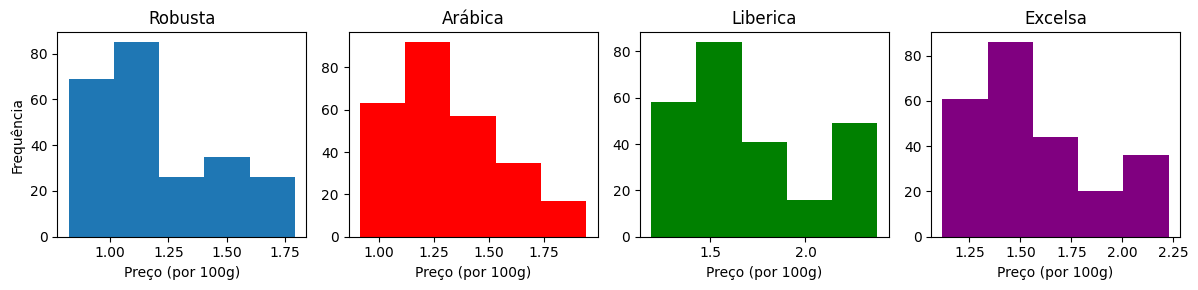

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols= 4, figsize=(12,3))

axes[0].hist(coffee_df.loc[coffee_df["Coffee Type"] == "Rob"]["Price per 100g"], bins=5)
axes[0].set_title('Robusta')
axes[0].set_xlabel("Preço (por 100g)")
axes[0].set_ylabel("Frequência")

axes[1].hist(coffee_df.loc[coffee_df["Coffee Type"] == "Ara"]["Price per 100g"], bins=5, color= "red")
axes[1].set_title('Arábica')
axes[1].set_xlabel("Preço (por 100g)")

axes[2].hist(coffee_df.loc[coffee_df["Coffee Type"] == "Lib"]["Price per 100g"], bins=5, color= "green")
axes[2].set_title('Liberica')
axes[2].set_xlabel("Preço (por 100g)")

axes[3].hist(coffee_df.loc[coffee_df["Coffee Type"] == "Exc"]["Price per 100g"], bins=5, color= "purple")
axes[3].set_title('Excelsa')
axes[3].set_xlabel("Preço (por 100g)")

#axes[1,0].hist(coffee_df.loc[(coffee_df["Coffee Type"] == "Ara") & (coffee_df["Roast Type"] == "L")]["Profit"], bins=5, color= "green")

plt.tight_layout()
plt.show()

### Box plot

In [ ]:
import plotly.express as px

fig = px.box(coffee_df, x="Coffee Type", y="Price per 100g")
fig.show()

TypeError: boxplot() got multiple values for argument 'x'

### Scatter plot

Text(0, 0.5, 'Valor da venda$*$')

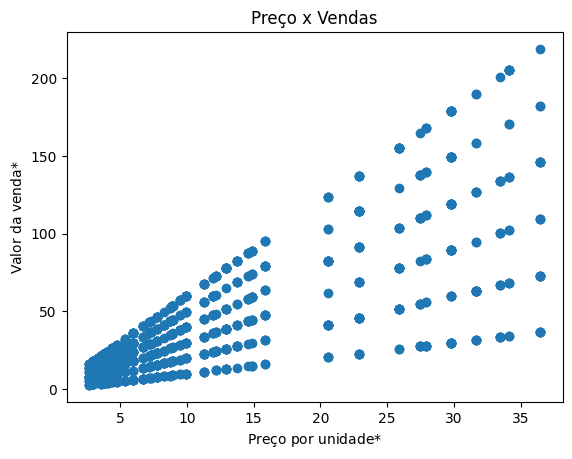

In [112]:
plt.scatter(coffee_df["Unit Price_products"], coffee_df["Sales"])
plt.title("Preço x Vendas")
plt.xlabel("Preço por unidade$*$")
plt.ylabel("Valor da venda$*$")


\*: A moeda em que os valores são dados não foi informada na descrição do autor do dataset. Porém, como a maioria dos registros de pedidos é dos Estados Unidos, pode-se supor que os valores estejam em dólares.